## Transfer Learning VGG16


Please download the dataset from the below url

In [1]:
# Environment and GPU check
import importlib
import sys
import tensorflow as tf

REQUIRED_PACKAGES = {
    'tensorflow': 'tensorflow',
    'keras': 'keras',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'PIL': 'pillow',
}

import_failures = []
for module_name, package_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module_name)
    except ModuleNotFoundError:
        import_failures.append(f'{package_name} (missing)')
    except Exception as exc:
        import_failures.append(f'{package_name} (import error: {exc})')

print(f'Python executable: {sys.executable}')
if 'venv' not in sys.executable.lower():
    print('Warning: select the plant-env notebook kernel if imports fail.')

if import_failures:
    raise RuntimeError(
        'Environment problems detected: ' + '; '.join(import_failures) + '. Reinstall with .\\venv\\Scripts\\python.exe -m pip install -r requirements.txt and reopen the notebook with the plant-env kernel.'
    )

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU devices found: {len(gpus)}')

Python executable: d:\projects\ML projects\plant disease final\venv\Scripts\python.exe
TensorFlow version: 2.12.0
GPU devices found: 0


In [2]:
# Import the libraries used in training
from glob import glob

import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [3]:
# re-size all the images to this
IMAGE_SIZE = [224, 224]

train_path = './dataset/train'
valid_path = './dataset/test'


In [4]:
# Build the VGG16 base model and fall back gracefully if pretrained weights are unavailable
try:
    inception = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
except Exception as exc:
    print(f'Could not load ImageNet VGG16 weights ({exc}). Falling back to weights=None.')
    inception = VGG16(input_shape=IMAGE_SIZE + [3], weights=None, include_top=False)


In [5]:
# don't train existing weights
for layer in inception.layers:
    layer.trainable = False

In [6]:
  # useful for getting number of output classes
folders = glob('./dataset/train/*')
folders

['./dataset/train\\0_Corn_Common_rust_',
 './dataset/train\\1_Potato___Early_blight',
 './dataset/train\\2_Tomato___Bacterial_spot',
 './dataset/train\\3_tomato_moldleaf',
 './dataset/train\\4_Tomato_healthy',
 './dataset/train\\5_Tomato_mosaic']

In [7]:
# Replace the flatten head with a pooled representation to reduce overfitting
x = GlobalAveragePooling2D()(inception.output)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)


In [8]:
prediction = Dense(len(folders), activation='softmax')(x)

# create a model object
model = Model(inputs=inception.input, outputs=prediction)


In [9]:

# view the structure of the model
model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [10]:
# Tell the model what cost and optimization method to use
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

print('Model compiled for VGG16 transfer learning')


Model compiled for VGG16 transfer learning


In [11]:
# Use the Image Data Generator to import the images from the dataset
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)


In [12]:
# Make sure you provide the same target size as initialied for the image size
# Increased batch size from 16 to 32 for faster training
training_set = train_datagen.flow_from_directory('./dataset/train',
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 387 images belonging to 6 classes.


In [13]:
test_set = test_datagen.flow_from_directory('./dataset/test',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical',shuffle=True)

Found 72 images belonging to 6 classes.


In [14]:
# Verify class counts match between train and test
from glob import glob

train_folders = sorted(glob('./dataset/train/*'))
test_folders = sorted(glob('./dataset/test/*'))

train_names = [f.split('\\')[-1] for f in train_folders]
test_names = [f.split('\\')[-1] for f in test_folders]

print(f"Training classes ({len(train_folders)}): {train_names}")
print(f"Test classes ({len(test_folders)}): {test_names}")

if len(train_folders) != len(test_folders):
    print(f"❌ WARNING: Mismatch! Train has {len(train_folders)} classes, Test has {len(test_folders)}")
else:
    print(f"✓ Class counts match: {len(train_folders)} classes each")


Training classes (6): ['0_Corn_Common_rust_', '1_Potato___Early_blight', '2_Tomato___Bacterial_spot', '3_tomato_moldleaf', '4_Tomato_healthy', '5_Tomato_mosaic']
Test classes (6): ['0_Corn_Common_rust_', '1_Potato___Early_blight', '2_Tomato___Bacterial_spot', '3_tomato_moldleaf', '4_Tomato_healthy', '5_Tomato_mosaic']
✓ Class counts match: 6 classes each


In [15]:
# fit the model - MobileNetV2 is much faster than VGG16
# Run the cell. It will take 3-5 minutes with batch_size=32
# Increased epochs to 10 for better accuracy
try:
    r = model.fit(
      training_set,
      validation_data=test_set,
      epochs=10,
      steps_per_epoch=len(training_set),
      validation_steps=len(test_set),
      verbose=1
    )
except Exception as e:
    print(f"Error during training: {e}")
    print("Try reducing batch_size in the training/test data generators above")
    raise

Epoch 1/10
 3/13 [=====>........................] - ETA: 18s - loss: 4.7810 - accuracy: 0.2083

d:\projects\ML projects\plant disease final\venv\lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


13/13 [==============================] - 31s 2s/step - loss: 3.6987 - accuracy: 0.3307 - val_loss: 1.5437 - val_accuracy: 0.5694
Epoch 2/10
13/13 [==============================] - 28s 2s/step - loss: 2.1329 - accuracy: 0.5220 - val_loss: 0.8177 - val_accuracy: 0.7222
Epoch 3/10
13/13 [==============================] - 33s 3s/step - loss: 1.5100 - accuracy: 0.6227 - val_loss: 0.5029 - val_accuracy: 0.8056
Epoch 4/10
13/13 [==============================] - 29s 2s/step - loss: 1.1663 - accuracy: 0.6718 - val_loss: 0.4054 - val_accuracy: 0.8611
Epoch 5/10
13/13 [==============================] - 31s 2s/step - loss: 0.9160 - accuracy: 0.7158 - val_loss: 0.4691 - val_accuracy: 0.8194
Epoch 6/10
13/13 [==============================] - 32s 2s/step - loss: 0.7833 - accuracy: 0.7571 - val_loss: 0.4555 - val_accuracy: 0.8611
Epoch 7/10
13/13 [==============================] - 28s 2s/step - loss: 0.8228 - accuracy: 0.7571 - val_loss: 0.4238 - val_accuracy: 0.8333
Epoch 8/10
13/13 [=============

In [16]:
# matplotlib already imported above, proceed to plotting

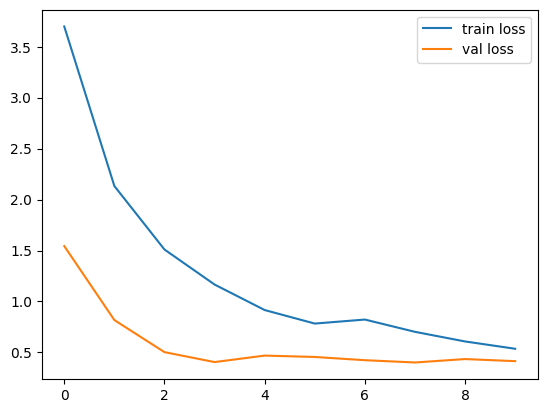

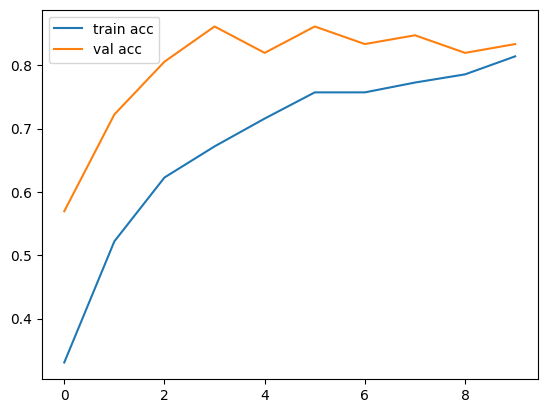

<Figure size 640x480 with 0 Axes>

In [17]:
# plot the loss
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

# plot the accuracy
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

In [18]:
# save it as a h5 file


from tensorflow.keras.models import load_model

model.save('model_vgg16.h5')